In [91]:
import json
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# load the trace patterns extracted in notebook 01
with open('trace_params.json') as f:
    trace_params = json.load(f)
stats = trace_params['stats']            # stats[day][hour] -> arrival_rate, avg_cpu, ...

# ---- cluster configuration ----
MIN_PODS = 2
MAX_PODS = 20
VM_CPU_CAP = 1.0                          # CPU capacity per VM
VM_MEM_CAP = 1.0                          # memory capacity per VM
JOBS_PER_STEP_PER_VM = 25                 # nominal throughput (for utilisation/state)

# ---- timing ----
STEP_MINUTES = 15
STEPS_PER_HOUR = 60 // STEP_MINUTES       # 4
STEPS_PER_DAY  = STEPS_PER_HOUR * 24      # 96
STEPS_PER_WEEK = STEPS_PER_DAY * 7        # 672  (one episode = one week)

# ---- workload scaling (calibrated so 2-20 VM range is meaningful) ----
WORKLOAD_SCALE = 0.008

# ---- reward weights (balanced config; varied later for Pareto frontier) ----
LAMBDA_COST = 0.4
LAMBDA_SLA  = 1.5
LAMBDA_UTIL = 0.1

print("Setup complete. Steps per week:", STEPS_PER_WEEK)

Setup complete. Steps per week: 672


In [92]:
class CloudClusterEnv(gym.Env):
    """Simulated cloud cluster. The agent chooses how many VMs to run,
    balancing cost against SLA compliance, using CPU and memory signals."""

    def __init__(self):
        super().__init__()
        # continuous action: one value in [-1, 1] -> scaling delta
        self.action_space = spaces.Box(-1.0, 1.0, shape=(1,), dtype=np.float32)
        # 32-dim observation (29 core + 3 hint slots)
        self.observation_space = spaces.Box(0.0, 1.0, shape=(32,), dtype=np.float32)

    # ---------------------------------------------------------------- reset
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_count = 0
        self.active_vms = 4
        self.queue = []
        self.cost_total = 0.0
        self.total_breaches = 0
        self.history = [[0.0, 0.0, 0.0, 0.0] for _ in range(5)]  # avg/max cpu, avg/max mem
        self.prev_queue_len = 0
        # hint slots (0 until synthetic-hint training / operator input)
        self.hint_active = 0.0
        self.hint_magnitude = 0.0
        self.hint_time_to_event = 0.0
        # decision log -> feeds the Phase 2 RAG explainability layer
        self.decision_log = []
        return self._build_state(), {}

    # --------------------------------------------------------- time helper
    def _current_day_hour(self):
        total_hours = self.step_count // STEPS_PER_HOUR
        hour = int(total_hours % 24)
        day = int((total_hours // 24) % 7)
        return day, hour

    # ------------------------------------------------------ job generation
    def _generate_jobs(self):
        day, hour = self._current_day_hour()
        s = stats[str(day)][str(hour)]
        jobs_this_step_mean = (s['arrival_rate'] * WORKLOAD_SCALE) / STEPS_PER_HOUR
        n_jobs = np.random.poisson(jobs_this_step_mean)
        deadline_by_class = {0: 2, 1: 4, 2: 8, 3: 16}
        new_jobs = []
        for _ in range(n_jobs):
            cpu = float(np.clip(np.random.normal(s['avg_cpu'], s['cpu_std']), 0.001, 1.0))
            mem = float(np.clip(np.random.normal(s['avg_mem'], s['mem_std']), 0.001, 1.0))
            sched = int(np.random.choice([0, 1, 2, 3], p=s['class_distribution']))
            new_jobs.append({'cpu': cpu, 'mem': mem,
                             'deadline': self.step_count + deadline_by_class[sched]})
        return new_jobs

    # ------------------------------------------------- assign jobs to VMs
    def _assign_jobs(self):
        vm_cpu_load = [0.0] * self.active_vms
        vm_mem_load = [0.0] * self.active_vms
        still_waiting = []
        jobs_processed = 0
        for job in self.queue:
            placed = False
            for vm_idx in sorted(range(self.active_vms), key=lambda i: vm_cpu_load[i]):
                cpu_ok = vm_cpu_load[vm_idx] + job['cpu'] <= VM_CPU_CAP
                mem_ok = vm_mem_load[vm_idx] + job['mem'] <= VM_MEM_CAP
                if cpu_ok and mem_ok:          # needs BOTH cpu and mem room
                    vm_cpu_load[vm_idx] += job['cpu']
                    vm_mem_load[vm_idx] += job['mem']
                    jobs_processed += 1
                    placed = True
                    break
            if not placed:
                still_waiting.append(job)
        self.queue = still_waiting
        if self.active_vms > 0:
            avg_cpu = float(np.mean(vm_cpu_load)); max_cpu = float(np.max(vm_cpu_load))
            avg_mem = float(np.mean(vm_mem_load)); max_mem = float(np.max(vm_mem_load))
        else:
            avg_cpu = max_cpu = avg_mem = max_mem = 0.0
        return jobs_processed, avg_cpu, max_cpu, avg_mem, max_mem

    # ---------------------------------------------------- deadline checks
    def _check_deadlines(self):
        breaches = 0
        surviving = []
        for job in self.queue:
            if self.step_count > job['deadline']:
                breaches += 1
            else:
                surviving.append(job)
        self.queue = surviving
        return breaches

    # ---------------------------------------------------------- the state
    def _build_state(self):
        hist = np.array(self.history, dtype=np.float32)
        avg_cpu_hist = hist[:, 0]; max_cpu_hist = hist[:, 1]
        avg_mem_hist = hist[:, 2]; max_mem_hist = hist[:, 3]

        capacity = self.active_vms * JOBS_PER_STEP_PER_VM
        queue_depth_ratio = float(np.clip(
            len(self.queue) / capacity if capacity > 0 else 1.0, 0.0, 1.0))

        growth = len(self.queue) - self.prev_queue_len
        queue_growth = float(np.clip(
            0.5 + (growth / capacity if capacity > 0 else 0.0), 0.0, 1.0))

        if len(self.queue) > 0:
            near = sum(1 for j in self.queue if j['deadline'] - self.step_count <= 2)
            sla_pressure = near / len(self.queue)
            slacks = [j['deadline'] - self.step_count for j in self.queue]
            min_slack = float(np.clip(min(slacks) / 16.0, 0.0, 1.0))
        else:
            sla_pressure = 0.0
            min_slack = 1.0

        active_vms_norm = self.active_vms / MAX_PODS
        cost_norm = float(np.clip(self.cost_total / STEPS_PER_WEEK, 0.0, 1.0))

        day, hour = self._current_day_hour()
        hour_sin = (np.sin(2 * np.pi * hour / 24) + 1) / 2
        hour_cos = (np.cos(2 * np.pi * hour / 24) + 1) / 2
        day_norm = day / 6.0

        hint = [self.hint_active, self.hint_magnitude, self.hint_time_to_event]

        return np.concatenate([
            avg_cpu_hist, max_cpu_hist, avg_mem_hist, max_mem_hist,
            [queue_depth_ratio], [queue_growth], [sla_pressure], [min_slack],
            [active_vms_norm], [cost_norm], [hour_sin], [hour_cos], [day_norm],
            hint,
        ]).astype(np.float32)

    # ----------------------------------------------------------- the step
    def step(self, action):
        # 1. apply action: [-1,1] -> up to +/-5 VMs
        delta = int(round(float(action[0]) * 5))
        self.active_vms = int(np.clip(self.active_vms + delta, MIN_PODS, MAX_PODS))

        # 2. generate jobs
        self.queue.extend(self._generate_jobs())

        # 3. assign to VMs (CPU + memory)
        jobs_processed, avg_cpu, max_cpu, avg_mem, max_mem = self._assign_jobs()

        # 4. deadlines -> breaches
        breaches = self._check_deadlines()
        self.total_breaches += breaches

        # 5. cost & utilisation
        cost = self.active_vms / MAX_PODS
        self.cost_total += cost
        # capacity = self.active_vms * JOBS_PER_STEP_PER_VM
        # utilisation = jobs_processed / capacity if capacity > 0 else 0.0
        utilisation = max(avg_cpu, avg_mem)

        # normalise breaches into a 0-1 rate so it can't dwarf cost
        jobs_due_this_step = jobs_processed + breaches   # rough denominator
        breach_rate = breaches / jobs_due_this_step if jobs_due_this_step > 0 else 0.0

        # 6. reward
        reward = (- LAMBDA_COST * cost
                  - LAMBDA_SLA * breach_rate
                  + LAMBDA_UTIL * utilisation)

        # 7. history (real memory values)
        self.history.append([avg_cpu, max_cpu, avg_mem, max_mem])
        self.history.pop(0)

        # log decision for Phase 2 RAG
        day, hour = self._current_day_hour()
        self.decision_log.append({
            'step': self.step_count, 'day': day, 'hour': hour,
            'active_vms': self.active_vms,
            'avg_cpu': round(avg_cpu, 3), 'avg_mem': round(avg_mem, 3),
            'queue': len(self.queue), 'breaches': breaches,
            'reward': round(reward, 3),
        })

        self.prev_queue_len = len(self.queue)
        self.step_count += 1

        obs = self._build_state()
        done = self.step_count >= STEPS_PER_WEEK
        info = {'cost': cost, 'breaches': breaches, 'utilisation': utilisation,
                'active_vms': self.active_vms, 'queue': len(self.queue),
                'avg_cpu': avg_cpu, 'avg_mem': avg_mem}
        return obs, reward, done, False, info

print("CloudClusterEnv defined.")

CloudClusterEnv defined.


In [93]:
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal

# import your environment from notebook 02
# (easiest for now: paste the CloudClusterEnv cell into this notebook too,
#  OR use %run — we'll handle imports cleanly in a moment)

class ActorCritic(nn.Module):
    def __init__(self, state_dim=32, action_dim=1):
        super().__init__()

        # shared body — both actor and critic read the state through this
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256),       nn.Tanh(),
        )

        # actor head: outputs the MEAN of the action distribution
        self.actor_mean = nn.Linear(256, action_dim)

        # a single learnable log-std (not state-dependent) — standard for PPO.
        # controls how much the agent explores around the mean.
        self.log_std = nn.Parameter(torch.zeros(action_dim))

        # critic head: outputs V(s), one number
        self.critic = nn.Linear(256, 1)

    def forward(self, state):
        x = self.shared(state)
        mean = self.actor_mean(x)
        value = self.critic(x)
        return mean, value

    def get_action(self, state):
        """Sample an action (training) and return its log-prob + value."""
        mean, value = self.forward(state)
        std = torch.exp(self.log_std)          # log_std -> std, always positive
        dist = Normal(mean, std)               # Gaussian over the action
        action = dist.sample()                 # sample for exploration
        log_prob = dist.log_prob(action).sum(-1)
        return action, log_prob, value.squeeze(-1)

    def evaluate_actions(self, state, action):
        """Used during the PPO update: re-score stored actions."""
        mean, value = self.forward(state)
        std = torch.exp(self.log_std)
        dist = Normal(mean, std)
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_prob, value.squeeze(-1), entropy


# quick shape test
net = ActorCritic()
dummy_state = torch.zeros(1, 32)
action, log_prob, value = net.get_action(dummy_state)
print("action:", action.shape, "log_prob:", log_prob.shape, "value:", value.shape)
print("Network built. Total params:",
      sum(p.numel() for p in net.parameters()))

action: torch.Size([1, 1]) log_prob: torch.Size([1]) value: torch.Size([1])
Network built. Total params: 74755


In [94]:
def compute_gae(rewards, values, dones, next_value, gamma=0.99, lam=0.95):
    """
    Turn a rollout into advantages using Generalised Advantage Estimation.

    rewards    : list of rewards, one per step
    values     : list of critic values V(s), one per step
    dones      : list of done flags (1 if episode ended at this step, else 0)
    next_value : critic's value estimate for the step AFTER the rollout
    gamma      : discount factor (how much future matters)
    lam        : GAE smoothing (bias-variance tradeoff)

    Returns: advantages (list) and returns (list, = advantages + values,
             used as the critic's training target).
    """
    advantages = []
    gae = 0.0
    values = values + [next_value]   # append bootstrap value at the end

    # walk BACKWARDS through the rollout
    for t in reversed(range(len(rewards))):
        # one-step TD error: reward + discounted next value - current value
        # (zeroed out across episode boundaries via (1 - dones[t]))
        delta = rewards[t] + gamma * values[t + 1] * (1 - dones[t]) - values[t]
        # accumulate the smoothed advantage
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)

    # returns = advantage + value  (target for the critic)
    returns = [adv + val for adv, val in zip(advantages, values[:-1])]
    return advantages, returns


# quick test on fake data to confirm it runs and shapes are right
fake_rewards = [1.0, -0.5, 0.2, 1.0]
fake_values  = [0.5, 0.3, 0.4, 0.6]
fake_dones   = [0, 0, 0, 1]           # episode ends on last step
adv, ret = compute_gae(fake_rewards, fake_values, fake_dones, next_value=0.0)
print("advantages:", [round(a, 3) for a in adv])
print("returns:   ", [round(r, 3) for r in ret])

advantages: [1.098, 0.32, 0.77, 0.4]
returns:    [1.598, 0.62, 1.17, 1.0]


In [95]:
def ppo_update(net, optimizer, states, actions, old_log_probs,
               advantages, returns,
               clip_eps=0.2, epochs=4, value_coef=0.5, entropy_coef=0.01):
    """
    Run the PPO update over one rollout.

    net           : the ActorCritic network
    states        : tensor [N, 32]
    actions       : tensor [N, 1]
    old_log_probs : tensor [N]   (log-probs from when actions were taken)
    advantages    : tensor [N]
    returns       : tensor [N]
    """
    # normalise advantages — stabilises training (standard practice)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    for _ in range(epochs):
        # re-score stored actions under the current policy
        new_log_probs, values, entropy = net.evaluate_actions(states, actions)

        # the PPO ratio: how much has the policy changed for these actions?
        ratio = torch.exp(new_log_probs - old_log_probs)

        # clipped surrogate objective
        unclipped = ratio * advantages
        clipped   = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
        actor_loss = -torch.min(unclipped, clipped).mean()   # minimise -> maximise reward

        # critic loss: value should predict the return
        critic_loss = ((values - returns) ** 2).mean()

        # entropy bonus: discourage collapsing to a single action
        entropy_loss = entropy.mean()

        # total loss
        loss = actor_loss + value_coef * critic_loss - entropy_coef * entropy_loss

        # gradient step
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 0.5)   # cap gradient size
        optimizer.step()

    return actor_loss.item(), critic_loss.item(), entropy_loss.item()


# quick test with fake data to confirm it runs
net = ActorCritic()
optimizer = torch.optim.Adam(net.parameters(), lr=3e-4)

N = 10
fake_states = torch.randn(N, 32)
fake_actions = torch.randn(N, 1)
fake_old_lp = torch.randn(N)
fake_adv = torch.randn(N)
fake_ret = torch.randn(N)

a_loss, c_loss, ent = ppo_update(net, optimizer, fake_states, fake_actions,
                                  fake_old_lp, fake_adv, fake_ret)
print(f"actor_loss: {a_loss:.4f}  critic_loss: {c_loss:.4f}  entropy: {ent:.4f}")
print("PPO update ran successfully.")

actor_loss: 0.1091  critic_loss: 1.4812  entropy: 1.4182
PPO update ran successfully.


In [96]:
def train(env, net, optimizer, total_steps=50_000, rollout_len=2048):
    """Train the PPO agent. Collects rollouts and updates repeatedly."""

    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32)

    steps_done = 0
    episode_reward = 0
    episode_rewards = []      # completed-episode returns, for tracking progress
    log = []                  # per-update summary

    while steps_done < total_steps:

        # ---- 1. COLLECT a rollout ----
        states, actions, log_probs = [], [], []
        rewards, values, dones = [], [], []

        for _ in range(rollout_len):
            with torch.no_grad():
                action, log_prob, value = net.get_action(state.unsqueeze(0))

            # step the environment
            a = action.squeeze(0).numpy()
            next_state, reward, done, truncated, info = env.step(a)

            # store
            states.append(state)
            actions.append(action.squeeze(0))
            log_probs.append(log_prob.squeeze(0))
            rewards.append(float(reward))
            values.append(value.item())
            dones.append(1.0 if done else 0.0)

            episode_reward += reward
            state = torch.tensor(next_state, dtype=torch.float32)
            steps_done += 1

            if done:
                episode_rewards.append(episode_reward)
                episode_reward = 0
                state, _ = env.reset()
                state = torch.tensor(state, dtype=torch.float32)

        # ---- 2. BOOTSTRAP value for the step after the rollout ----
        with torch.no_grad():
            _, _, next_value = net.get_action(state.unsqueeze(0))
            next_value = next_value.item()

        # ---- 3. GAE ----
        advantages, returns = compute_gae(rewards, values, dones, next_value)

        # ---- 4. UPDATE ----
        b_states  = torch.stack(states)
        b_actions = torch.stack(actions)
        b_old_lp  = torch.stack(log_probs)
        b_adv     = torch.tensor(advantages, dtype=torch.float32)
        b_ret     = torch.tensor(returns, dtype=torch.float32)

        a_loss, c_loss, ent = ppo_update(net, optimizer, b_states, b_actions,
                                          b_old_lp, b_adv, b_ret)

        # ---- 5. LOG ----
        recent = np.mean(episode_rewards[-5:]) if episode_rewards else float('nan')
        log.append({'steps': steps_done, 'recent_ep_reward': recent,
                    'actor_loss': a_loss, 'critic_loss': c_loss})
        print(f"steps {steps_done:6d} | recent ep reward {recent:10.1f} | "
              f"actor {a_loss:+.3f} critic {c_loss:.3f} entropy {ent:.3f}")

    return episode_rewards, log

In [100]:
# smoke test: short run to confirm learning
env = CloudClusterEnv()
net = ActorCritic()
optimizer = torch.optim.Adam(net.parameters(), lr=3e-4)

print("Starting smoke-test training (50k steps)...\n")
episode_rewards, log = train(env, net, optimizer, total_steps=250_000)

print(f"\nEpisodes completed: {len(episode_rewards)}")
if len(episode_rewards) >= 2:
    print(f"First episode reward: {episode_rewards[0]:.1f}")
    print(f"Last episode reward:  {episode_rewards[-1]:.1f}")

Starting smoke-test training (50k steps)...

steps   2048 | recent ep reward     -160.3 | actor -0.001 critic 19.920 entropy 1.418
steps   4096 | recent ep reward     -167.4 | actor -0.001 critic 19.294 entropy 1.418
steps   6144 | recent ep reward     -152.9 | actor -0.002 critic 15.673 entropy 1.418
steps   8192 | recent ep reward     -161.4 | actor -0.000 critic 19.045 entropy 1.418
steps  10240 | recent ep reward     -159.3 | actor -0.002 critic 19.546 entropy 1.419
steps  12288 | recent ep reward     -151.9 | actor +0.000 critic 12.142 entropy 1.419
steps  14336 | recent ep reward     -155.9 | actor -0.004 critic 15.643 entropy 1.420
steps  16384 | recent ep reward     -157.7 | actor +0.000 critic 10.710 entropy 1.420
steps  18432 | recent ep reward     -157.3 | actor -0.000 critic 8.300 entropy 1.421
steps  20480 | recent ep reward     -163.2 | actor +0.001 critic 9.615 entropy 1.422
steps  22528 | recent ep reward     -171.5 | actor -0.001 critic 11.398 entropy 1.422
steps  2457

In [104]:
torch.save(net.state_dict(), 'ppo_smoketest_3.pth')
print("Saved.")

Saved.


In [102]:
def run_rule_based(env, up_threshold=0.70, down_threshold=0.30):
    """
    Rule-based HPA-equivalent baseline. Scales on a fixed CPU threshold,
    exactly like Kubernetes Horizontal Pod Autoscaler. Runs one full
    episode (one week) and returns the metrics.
    """
    obs, _ = env.reset()

    total_reward = 0.0
    total_cost = 0.0
    total_breaches = 0
    total_util = 0.0
    vm_counts = []
    steps = 0

    for t in range(STEPS_PER_WEEK):
        # HPA looks at CURRENT average CPU (the most recent history entry)
        # history[-1] = [avg_cpu, max_cpu, avg_mem, max_mem]
        current_avg_cpu = env.history[-1][0]

        # threshold decision → convert to an action in [-1, 1]
        if current_avg_cpu > up_threshold:
            action = np.array([0.2])      # scale up (small positive)
        elif current_avg_cpu < down_threshold:
            action = np.array([-0.2])     # scale down (small negative)
        else:
            action = np.array([0.0])      # hold

        obs, reward, done, truncated, info = env.step(action)

        total_reward += reward
        total_cost += info['cost']
        total_breaches += info['breaches']
        total_util += info['utilisation']
        vm_counts.append(info['active_vms'])
        steps += 1
        if done:
            break

    return {
        'total_reward': total_reward,
        'total_cost': total_cost,
        'total_breaches': total_breaches,
        'avg_utilisation': total_util / steps,
        'avg_vms': np.mean(vm_counts),
    }


# run the baseline over several episodes and average (workload is random)
print("Running rule-based HPA baseline (5 episodes)...\n")
env = CloudClusterEnv()
results = [run_rule_based(env) for _ in range(5)]

# average the metrics across episodes
baseline = {
    'total_cost':      np.mean([r['total_cost'] for r in results]),
    'total_breaches':  np.mean([r['total_breaches'] for r in results]),
    'avg_utilisation': np.mean([r['avg_utilisation'] for r in results]),
    'avg_vms':         np.mean([r['avg_vms'] for r in results]),
    'total_reward':    np.mean([r['total_reward'] for r in results]),
}

print("RULE-BASED (HPA-equivalent) BASELINE — averaged over 5 weeks:")
print(f"  Total cost:        {baseline['total_cost']:.1f}")
print(f"  Total SLA breaches:{baseline['total_breaches']:.0f}")
print(f"  Avg utilisation:   {baseline['avg_utilisation']:.3f}")
print(f"  Avg VMs used:      {baseline['avg_vms']:.1f}")
print(f"  Total reward:      {baseline['total_reward']:.1f}")

Running rule-based HPA baseline (5 episodes)...

RULE-BASED (HPA-equivalent) BASELINE — averaged over 5 weeks:
  Total cost:        292.5
  Total SLA breaches:1669
  Avg utilisation:   0.560
  Avg VMs used:      8.7
  Total reward:      -82.8


In [103]:
def run_ppo(env, net, n_episodes=5):
    """Run the trained PPO agent (deterministic: use the mean action)
    over several weeks and average the metrics."""
    all_results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        obs = torch.tensor(obs, dtype=torch.float32)
        total_cost = total_breaches = total_util = 0.0
        vm_counts = []
        steps = 0
        for t in range(STEPS_PER_WEEK):
            with torch.no_grad():
                mean, _ = net.forward(obs.unsqueeze(0))   # MEAN = deterministic
            action = mean.squeeze(0).numpy()
            obs, reward, done, truncated, info = env.step(action)
            obs = torch.tensor(obs, dtype=torch.float32)
            total_cost += info['cost']
            total_breaches += info['breaches']
            total_util += info['utilisation']
            vm_counts.append(info['active_vms'])
            steps += 1
            if done:
                break
        all_results.append({
            'total_cost': total_cost,
            'total_breaches': total_breaches,
            'avg_utilisation': total_util / steps,
            'avg_vms': np.mean(vm_counts),
        })
    return all_results

print("Running trained PPO agent (5 episodes)...\n")
env = CloudClusterEnv()
ppo_results = run_ppo(env, net, n_episodes=5)

ppo = {
    'total_cost':      np.mean([r['total_cost'] for r in ppo_results]),
    'total_breaches':  np.mean([r['total_breaches'] for r in ppo_results]),
    'avg_utilisation': np.mean([r['avg_utilisation'] for r in ppo_results]),
    'avg_vms':         np.mean([r['avg_vms'] for r in ppo_results]),
}

# ---- side by side ----
print("="*52)
print(f"{'METRIC':<22}{'Rule-based':>14}{'PPO':>14}")
print("="*52)
print(f"{'Total cost':<22}{baseline['total_cost']:>14.1f}{ppo['total_cost']:>14.1f}")
print(f"{'SLA breaches':<22}{baseline['total_breaches']:>14.0f}{ppo['total_breaches']:>14.0f}")
print(f"{'Utilisation':<22}{baseline['avg_utilisation']:>14.3f}{ppo['avg_utilisation']:>14.3f}")
print(f"{'Avg VMs':<22}{baseline['avg_vms']:>14.1f}{ppo['avg_vms']:>14.1f}")
print("="*52)

# quick verdict
cost_diff = (ppo['total_cost'] - baseline['total_cost']) / baseline['total_cost'] * 100
breach_diff = (ppo['total_breaches'] - baseline['total_breaches']) / baseline['total_breaches'] * 100
print(f"\nPPO vs rule-based:")
print(f"  cost:     {cost_diff:+.1f}%")
print(f"  breaches: {breach_diff:+.1f}%")

Running trained PPO agent (5 episodes)...

METRIC                    Rule-based           PPO
Total cost                     292.5         178.3
SLA breaches                    1669          1474
Utilisation                    0.560         0.955
Avg VMs                          8.7           5.3

PPO vs rule-based:
  cost:     -39.1%
  breaches: -11.7%


In [105]:
import time

# ── Pareto configurations: from cost-focused to SLA-focused ──────────────
pareto_configs = [
    {'name': 'cost-focused',  'cost': 0.8, 'sla': 0.5, 'util': 0.1},
    {'name': 'balanced-cost', 'cost': 0.5, 'sla': 1.0, 'util': 0.1},
    {'name': 'balanced-sla',  'cost': 0.4, 'sla': 1.5, 'util': 0.1},
    {'name': 'sla-focused',   'cost': 0.3, 'sla': 2.5, 'util': 0.1},
]

pareto_results = []

for cfg in pareto_configs:
    print(f"\n{'='*55}")
    print(f"Training config: {cfg['name']} "
          f"(cost={cfg['cost']}, sla={cfg['sla']})")
    print('='*55)

    # set the global lambdas this config uses
    global LAMBDA_COST, LAMBDA_SLA, LAMBDA_UTIL
    LAMBDA_COST = cfg['cost']
    LAMBDA_SLA  = cfg['sla']
    LAMBDA_UTIL = cfg['util']

    # fresh network, train from scratch
    env = CloudClusterEnv()
    net_cfg = ActorCritic()
    optimizer = torch.optim.Adam(net_cfg.parameters(), lr=3e-4)

    t0 = time.time()
    train(env, net_cfg, optimizer, total_steps=250_000)
    mins = (time.time() - t0) / 60

    # evaluate this config (deterministic, 5 weeks averaged)
    eval_env = CloudClusterEnv()
    results = run_ppo(eval_env, net_cfg, n_episodes=5)
    avg_cost     = np.mean([r['total_cost'] for r in results])
    avg_breaches = np.mean([r['total_breaches'] for r in results])
    avg_util     = np.mean([r['avg_utilisation'] for r in results])
    avg_vms      = np.mean([r['avg_vms'] for r in results])

    pareto_results.append({
        'name': cfg['name'],
        'lambda_cost': cfg['cost'], 'lambda_sla': cfg['sla'],
        'cost': avg_cost, 'breaches': avg_breaches,
        'utilisation': avg_util, 'avg_vms': avg_vms,
    })

    # save each model
    torch.save(net_cfg.state_dict(), f"ppo_{cfg['name']}.pth")
    print(f"\n  → cost {avg_cost:.1f} | breaches {avg_breaches:.0f} | "
          f"VMs {avg_vms:.1f} | trained in {mins:.1f} min")

print("\n\nALL CONFIGS DONE. Summary:")
print(f"{'config':<16}{'cost':>8}{'breaches':>10}{'avg_vms':>9}")
for r in pareto_results:
    print(f"{r['name']:<16}{r['cost']:>8.1f}{r['breaches']:>10.0f}{r['avg_vms']:>9.1f}")


Training config: cost-focused (cost=0.8, sla=0.5)
steps   2048 | recent ep reward     -283.3 | actor -0.018 critic 46.330 entropy 1.420
steps   4096 | recent ep reward     -260.7 | actor -0.020 critic 32.742 entropy 1.421
steps   6144 | recent ep reward     -229.8 | actor -0.018 critic 25.847 entropy 1.420
steps   8192 | recent ep reward     -180.9 | actor -0.011 critic 10.656 entropy 1.419
steps  10240 | recent ep reward     -136.8 | actor -0.007 critic 8.369 entropy 1.418
steps  12288 | recent ep reward     -119.0 | actor -0.001 critic 5.635 entropy 1.417
steps  14336 | recent ep reward     -102.6 | actor +0.000 critic 5.480 entropy 1.416
steps  16384 | recent ep reward      -99.6 | actor -0.000 critic 5.436 entropy 1.416
steps  18432 | recent ep reward      -98.7 | actor -0.001 critic 5.650 entropy 1.416
steps  20480 | recent ep reward      -99.2 | actor +0.000 critic 5.678 entropy 1.416
steps  22528 | recent ep reward      -99.7 | actor -0.002 critic 5.795 entropy 1.417
steps  245

In [106]:
import json
with open('pareto_results.json', 'w') as f:
    json.dump(pareto_results, f, indent=2)
print("Pareto results saved.")

Pareto results saved.


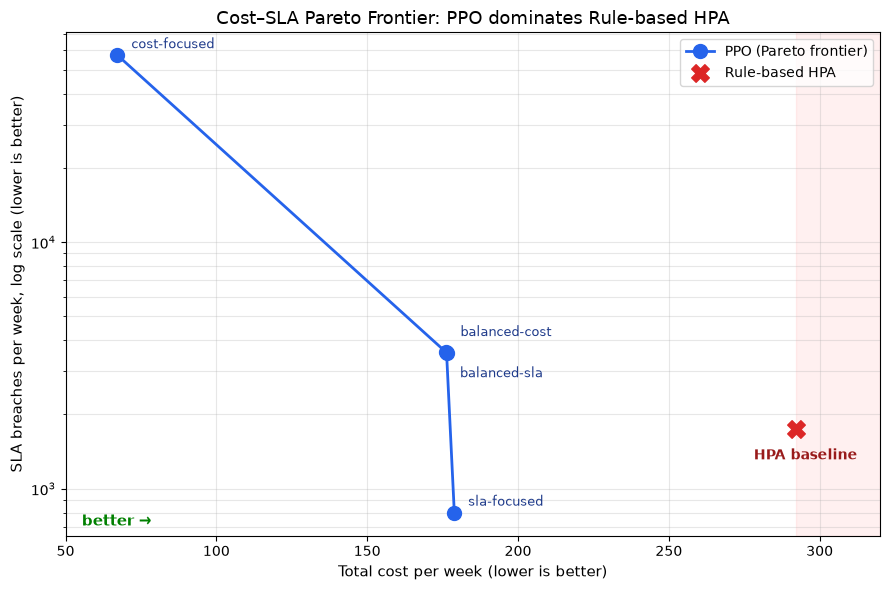

In [110]:
import matplotlib.pyplot as plt

# baseline (use your measured numbers)
baseline_cost, baseline_breaches = 292.0, 1750.0

# PPO points — relabel for clarity, drop the duplicate middle label
pts = sorted(zip(ppo_costs, ppo_breaches, ppo_names))
sc = [p[0] for p in pts]; sb = [p[1] for p in pts]; sn = [p[2] for p in pts]

fig, ax = plt.subplots(figsize=(9, 6))

# shade the region that is WORSE than HPA on both axes (upper-right of PPO)
ax.axvspan(baseline_cost, ax.get_xlim()[1] if False else 320,
           alpha=0.06, color='red')

ax.plot(sc, sb, '-o', color='#2563eb', linewidth=2, markersize=10,
        label='PPO (Pareto frontier)', zorder=3)

# smarter label placement — offset each differently to avoid overlap
offsets = {'cost-focused': (10, 5), 'balanced-cost': (10, 12),
           'balanced-sla': (10, -18), 'sla-focused': (10, 5)}
for c, b, n in zip(sc, sb, sn):
    off = offsets.get(n, (8, 8))
    ax.annotate(n, (c, b), textcoords="offset points", xytext=off,
                fontsize=9, color='#1e3a8a')

ax.scatter([baseline_cost], [baseline_breaches], color='#dc2626',
           s=160, marker='X', label='Rule-based HPA', zorder=4)
ax.annotate('HPA baseline', (baseline_cost, baseline_breaches),
            textcoords="offset points", xytext=(-30, -22),
            fontsize=10, color='#991b1b', fontweight='bold')

ax.set_yscale('log')
ax.set_xlim(50, 320)
ax.set_xlabel('Total cost per week (lower is better)', fontsize=11)
ax.set_ylabel('SLA breaches per week, log scale (lower is better)', fontsize=11)
ax.set_title('Cost–SLA Pareto Frontier: PPO dominates Rule-based HPA', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, which='both')
ax.text(0.02, 0.02, 'better →', transform=ax.transAxes,
        fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

In [111]:
print("FINAL PARETO + BASELINE NUMBERS (for dissertation):")
print(f"  HPA baseline:  cost {baseline_cost:.0f}, breaches {baseline_breaches:.0f}")
for r in pareto_results:
    print(f"  {r['name']:<14}: cost {r['cost']:.0f}, breaches {r['breaches']:.0f}, VMs {r['avg_vms']:.1f}")

FINAL PARETO + BASELINE NUMBERS (for dissertation):
  HPA baseline:  cost 292, breaches 1750
  cost-focused  : cost 67, breaches 57375, VMs 2.0
  balanced-cost : cost 176, breaches 3560, VMs 5.2
  balanced-sla  : cost 176, breaches 3577, VMs 5.2
  sla-focused   : cost 179, breaches 799, VMs 5.3
